# Local registration with ICP

In the RGBD folder we have the first 400 images from one of the datasets from: [http://redwood-data.org/indoor_lidar_rgbd/download.html](http://redwood-data.org/indoor_lidar_rgbd/download.html)

In [1]:
import os
import open3d as o3d
import matplotlib.pyplot as plt
import numpy as np
import copy

os.environ["XDG_SESSION_TYPE"] = "x11"

# Show two point clouds (orange=source, blue=target)
def draw_registrations(source, target, transformation=None, recolor=False):
    src = copy.deepcopy(source)
    tgt = copy.deepcopy(target)

    if recolor:
        src.paint_uniform_color([1, 0.706, 0])  # Orange
        tgt.paint_uniform_color([0, 0.651, 0.929])  # Blue

    if transformation is not None:
        src.transform(transformation)

    o3d.visualization.draw_geometries([src, tgt])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Creating point clouds from image data
Now we are going to try to create our own point clouds from RGB+depth images.
First, we load two RGBD images.

In [2]:
# Read in images. We have images 000000 - 0000400
color_raw0 = o3d.io.read_image("RGBD/color/000000.jpg")
depth_raw0 = o3d.io.read_image("RGBD/depth/000000.png")

color_raw1 = o3d.io.read_image("RGBD/color/000005.jpg")
depth_raw1 = o3d.io.read_image("RGBD/depth/000005.png")

Create point clouds from rgb + depth images.

If you set `convert_rgb_to_intensity = False` you will retain the colors from the rgb image.

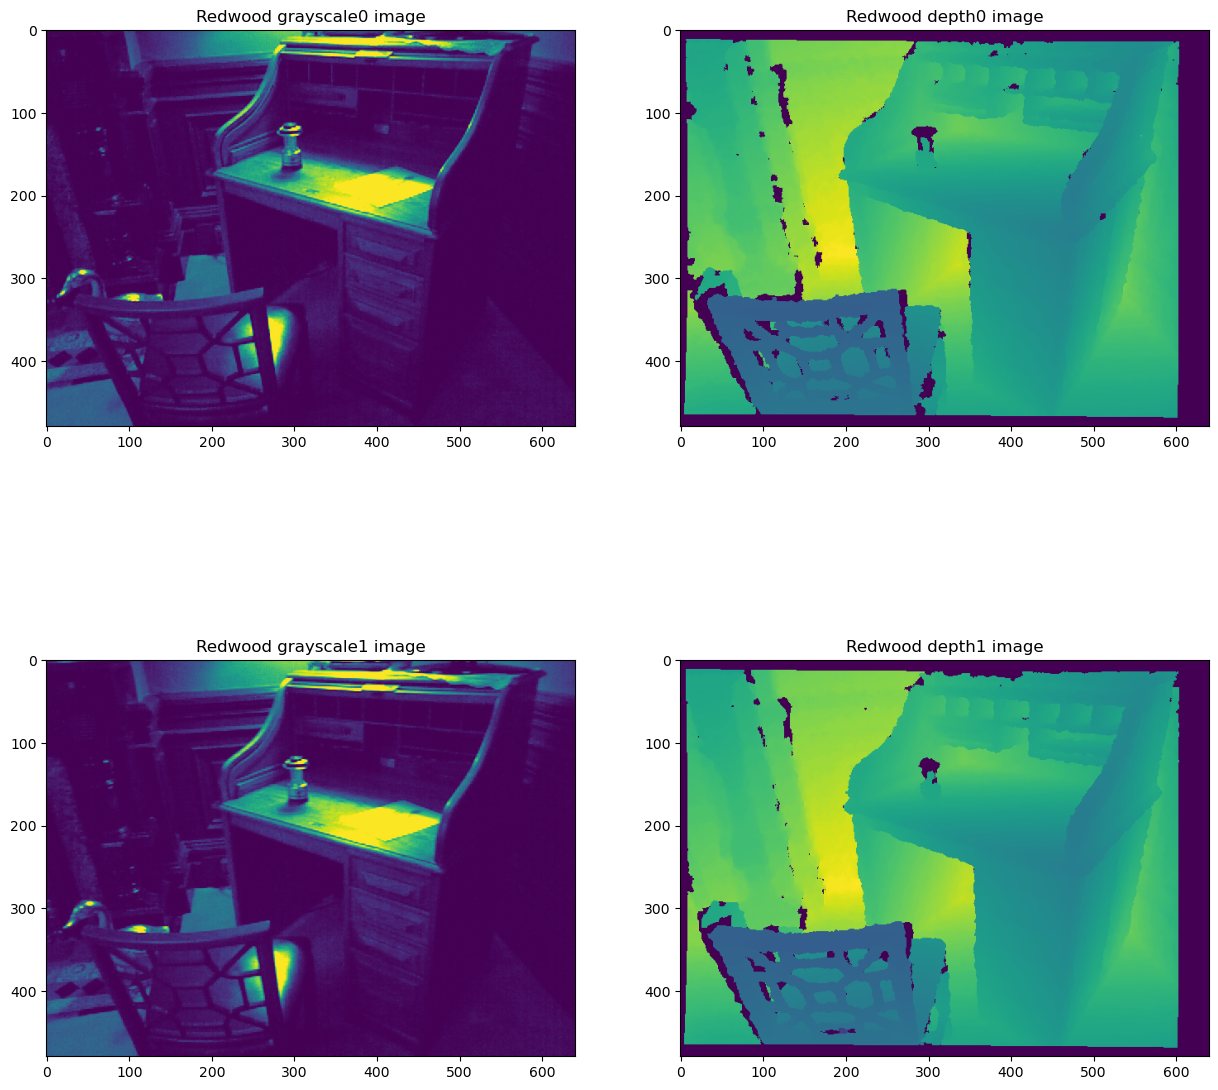

In [3]:
rgbd_image0 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw0, 
    depth_raw0, 
    convert_rgb_to_intensity = True)

rgbd_image1 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw1, 
    depth_raw1, 
    convert_rgb_to_intensity = True)

#show images
fig= plt.figure(figsize=(15,15))
plt.subplot(221)
plt.title('Redwood grayscale0 image')
plt.imshow(rgbd_image0.color)

plt.subplot(222)
plt.title('Redwood depth0 image')
plt.imshow(rgbd_image0.depth)

plt.subplot(223)
plt.title('Redwood grayscale1 image')
plt.imshow(rgbd_image1.color)

plt.subplot(224)
plt.title('Redwood depth1 image')
plt.imshow(rgbd_image1.depth)

plt.show()


## Images to point cloud
Now we create point clouds from the RGBD images we just loaded/created.


Here, we use `PinholeCameraIntrinsicParameters.PrimeSenseDefault` as default camera parameters. 

It has an image resolution of 640x480, focal length of ($f_x$, $f_y$) = (525.0, 525.0), and optical center ($c_x$, $c_y$) = (319.5, 239.5). 

An identity matrix is used as default extrinsic parameters. `pcd.transform` applies an up-down flip transformation on the point cloud for an improved visualization.


If execution becomes too slow you can downsample the point cloud.

In [4]:
# Source pointcloud
camera = o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault)

source = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image0, camera)

# Target pointcloud
target = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image1, camera)

# Flip it, otherwise the pointcloud will be upside down
source.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
target.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

# Draw
draw_registrations(source, target, recolor=True)


### Evaluation of pointclouds

Before we can run ICP, we evaluate our source and target point clouds. This gives us a feeling if we need a better initial transformation or not.
From (http://www.open3d.org/docs/latest/tutorial/Basic/icp_registration.html):

"The function `evaluate_registration` calculates two main metrics. 
- `fitness` measures the overlapping area (# of inlier correspondences / # of points in target). The higher the better. 
- `inlier_rmse` measures the RMSE of all inlier correspondences. The lower the better.

In [5]:
# Parameters
threshold = 0.02
trans_init = np.asarray([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])

#Evaluate registration
print("Initial alignment")
evaluation = o3d.pipelines.registration.evaluate_registration(source, target, threshold, trans_init)
print(evaluation)

Initial alignment
RegistrationResult with fitness=9.176427e-01, inlier_rmse=9.789196e-03, and correspondence_set size of 240059
Access transformation to get result.


## ICP

Now try to call icp with your point clouds and your initial transformation.

Initially we use:
```Python
point_to_plane =  o3d.pipelines.registration.TransformationEstimationPointToPlane()
icp_result = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    point_to_plane)
```

In [6]:
# Run ICP
icp_result = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPoint())

print(f"Fitness: {icp_result.fitness:.4f}")
print(f"RMSE: {icp_result.inlier_rmse:.4f}")

draw_registrations(source, target, icp_result.transformation, True)


=== Running ICP (Point-to-Point) ===
Fitness: 0.9902
RMSE: 0.0054
Transformation:
[[ 9.99937375e-01  5.20628080e-03 -9.90664617e-03  9.36722185e-04]
 [-5.14535899e-03  9.99967757e-01  6.16517162e-03 -6.06056627e-04]
 [ 9.93842436e-03 -6.11381227e-03  9.99931922e-01 -1.10747695e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


# Exercises

### A)
If you increase the amount of steps from the original image so from i.e. 000000.jpg<>000005.jpg to 00000.jpg<>000300.jpg, what happens?
### B)
Can you tweak the parameters `threshold` and `trans_init` to combat some of the ill effects that starts appearing?
### C)
Again try to use 
```Python
point_to_plane =  o3d.pipelines.registration.TransformationEstimationPointToPlane()

reg_p2p = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    point_to_plane)
```

This requires you to find the normals for each point cloud use:
```python
    source.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.5,
                            max_nn=30),fast_normal_computation=True)
```
Compare the resulting translations of the two methods. Is one better than the other?
### D)
Extend this and try to see how much of the bedroom you can reconstruct from the RGB and depth images.
You can extend a point cloud by `new = source + target`. Remember to resample the point cloud after a view additions so it does not get too large: `down_source = source.voxel_down_sample(voxel_size=0.05)`

## Exercise A: Testing with Large Step Differences

In [ ]:
print("=== Exercise A: Large Frame Gap (0 to 300) ===")

# Load distant frames
rgbd_a0 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    o3d.io.read_image("RGBD/color/000000.jpg"),
    o3d.io.read_image("RGBD/depth/000000.png"))

rgbd_a1 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    o3d.io.read_image("RGBD/color/000300.jpg"),
    o3d.io.read_image("RGBD/depth/000300.png"))

source_a = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_a0, camera)
target_a = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_a1, camera)

source_a.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
target_a.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

# Run ICP
icp_a = o3d.pipelines.registration.registration_icp(
    source_a, target_a, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPoint())

print(f"Fitness: {icp_a.fitness:.4f} (much worse!)")
print(f"RMSE: {icp_a.inlier_rmse:.4f}")
print("→ ICP fails when frames are too far apart")

draw_registrations(source_a, target_a, icp_a.transformation, True)

## Exercise B: Tweaking Parameters for Better Results

In [ ]:
print("=== Exercise B: Fix with Larger Threshold ===")

# Increase threshold for distant frames
threshold_b = 0.05  # Was 0.02

icp_b = o3d.pipelines.registration.registration_icp(
    source_a, target_a, threshold_b, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPoint(),
    o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100))

print(f"Fitness: {icp_b.fitness:.4f} (was {icp_a.fitness:.4f})")
print(f"RMSE: {icp_b.inlier_rmse:.4f}")
print("→ Larger threshold helps!")

draw_registrations(source_a, target_a, icp_b.transformation, True)

## Exercise C: Point-to-Point vs Point-to-Plane

In [ ]:
print("=== Exercise C: Point-to-Point vs Point-to-Plane ===")

# Estimate normals (needed for Point-to-Plane)
source.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
target.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

# 1. Point-to-Point
icp_p2p = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPoint())

# 2. Point-to-Plane
icp_p2pl = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPlane())

# Compare
print(f"Point-to-Point: Fitness={icp_p2p.fitness:.4f}, RMSE={icp_p2p.inlier_rmse:.4f}")
print(f"Point-to-Plane: Fitness={icp_p2pl.fitness:.4f}, RMSE={icp_p2pl.inlier_rmse:.4f}")

if icp_p2pl.inlier_rmse < icp_p2p.inlier_rmse:
    print("→ Point-to-Plane is better!")
else:
    print("→ Point-to-Point is better!")

draw_registrations(source, target, icp_p2pl.transformation, True)

## Exercise D: Reconstruct the Bedroom

In [ ]:
print("=== Exercise D: Bedroom Reconstruction ===")

# Start with first frame
rgbd0 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    o3d.io.read_image("RGBD/color/000000.jpg"),
    o3d.io.read_image("RGBD/depth/000000.png"),
    convert_rgb_to_intensity=False)

accumulated = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd0, camera)
accumulated.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

# Process every 10th frame (0 to 200)
print("Processing frames...")
for i, idx in enumerate(range(10, 200, 10)):
    print(f"Frame {idx}...")

    # Load frame
    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        o3d.io.read_image(f"RGBD/color/{idx:06d}.jpg"),
        o3d.io.read_image(f"RGBD/depth/{idx:06d}.png"),
        convert_rgb_to_intensity=False)

    new_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, camera)
    new_pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

    # Estimate normals
    accumulated.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    new_pcd.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

    # Align with ICP
    result = o3d.pipelines.registration.registration_icp(
        new_pcd, accumulated, 0.05, np.eye(4),
        o3d.pipelines.registration.TransformationEstimationPointToPlane(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=50))

    # Add to model
    new_pcd.transform(result.transformation)
    accumulated = accumulated + new_pcd

    # Downsample every 5 frames
    if (i + 1) % 5 == 0:
        accumulated = accumulated.voxel_down_sample(0.01)

# Final cleanup
accumulated = accumulated.voxel_down_sample(0.01)
print(f"Done! Points: {len(accumulated.points)}")

# Show result
o3d.visualization.draw_geometries([accumulated])
